In [1]:
import allel

In [4]:
vcf = allel.read_vcf(
    r"C:\Users\PC\OneDrive\Desktop\data\ALL.chr20.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz",
    fields=["samples", "calldata/GT", "variants/POS"]
)

In [5]:
print(vcf.keys())

dict_keys(['samples', 'calldata/GT', 'variants/POS'])


In [7]:
print(vcf["calldata/GT"].shape)

(1812841, 2504, 2)


In [8]:
gt = vcf["calldata/GT"][:10000, :100]

In [9]:
print(gt.shape)

(10000, 100, 2)


In [10]:
gn = gt[:, :, 0] + gt[:, :, 1]

In [11]:
print(gn.shape)

(10000, 100)


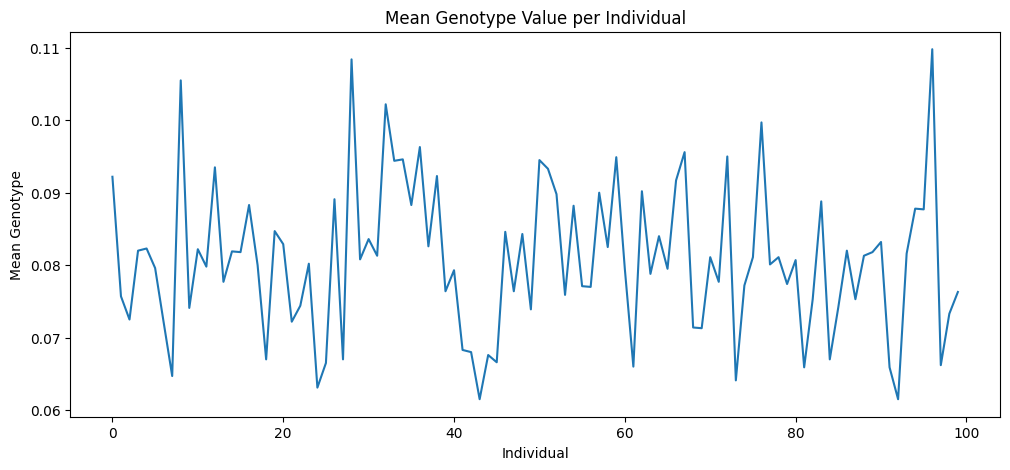

In [12]:
import matplotlib.pyplot as plt
import numpy as np

mean_genotype = np.mean(gn, axis=0)

plt.figure(figsize=(12,5))
plt.plot(mean_genotype)
plt.title("Mean Genotype Value per Individual")
plt.xlabel("Individual")
plt.ylabel("Mean Genotype")
plt.show()

In [13]:
degraded = gn.copy()

mask = np.random.rand(*degraded.shape) < 0.3
degraded[mask] = -1

In [14]:
missing_rate = np.mean(degraded == -1)

print("Missing rate:", missing_rate)

Missing rate: 0.299301


In [15]:
reference = gn.T
query = degraded.T

In [16]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(query, reference)

In [17]:
predicted = similarity_matrix.argmax(axis=1)

In [18]:
true_ids = np.arange(reference.shape[0])

accuracy = np.mean(predicted == true_ids)

print("Identification accuracy:", accuracy)

Identification accuracy: 1.0


In [19]:
degradation_levels = [0.1, 0.3, 0.5, 0.7, 0.9]
accuracies = []

for level in degradation_levels:

    degraded = gn.copy()

    mask = np.random.rand(*degraded.shape) < level
    degraded[mask] = -1

    reference = gn.T
    query = degraded.T

    similarity_matrix = cosine_similarity(query, reference)

    predicted = similarity_matrix.argmax(axis=1)

    true_ids = np.arange(reference.shape[0])

    accuracy = np.mean(predicted == true_ids)

    accuracies.append(accuracy)

    print(f"Degradation {level:.1f} -> Accuracy {accuracy:.3f}")

Degradation 0.1 -> Accuracy 1.000
Degradation 0.3 -> Accuracy 1.000
Degradation 0.5 -> Accuracy 1.000
Degradation 0.7 -> Accuracy 0.460
Degradation 0.9 -> Accuracy 0.050


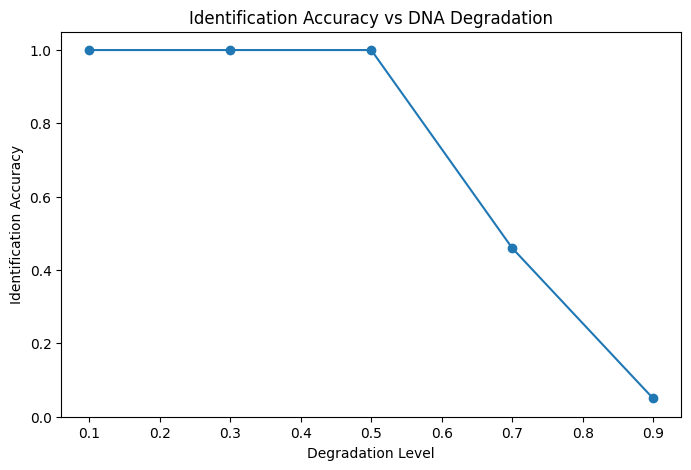

In [20]:
plt.figure(figsize=(8,5))

plt.plot(degradation_levels, accuracies, marker='o')

plt.title("Identification Accuracy vs DNA Degradation")
plt.xlabel("Degradation Level")
plt.ylabel("Identification Accuracy")

plt.ylim(0, 1.05)

plt.show()

In [21]:
plt.savefig("degradation_accuracy_curve.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [22]:

mix_1 = 0.7 * gn[:, 0] + 0.3 * gn[:, 1]
mix_2 = 0.5 * gn[:, 2] + 0.5 * gn[:, 3]
mix_3 = 0.9 * gn[:, 4] + 0.1 * gn[:, 5]

mixed_samples = np.vstack([mix_1, mix_2, mix_3])

print(mixed_samples.shape)

(3, 10000)


In [23]:
reference = gn.T

mix_similarity = cosine_similarity(mixed_samples, reference)

top_matches = np.argsort(mix_similarity, axis=1)[:, -5:][:, ::-1]

print(top_matches)

[[ 0  1 90 30 14]
 [ 3 13 31  1 78]
 [ 4 13 11  1  0]]


In [24]:
for i, matches in enumerate(top_matches):
    print(f"Mixture {i+1} top matches:", matches)

Mixture 1 top matches: [ 0  1 90 30 14]
Mixture 2 top matches: [ 3 13 31  1 78]
Mixture 3 top matches: [ 4 13 11  1  0]


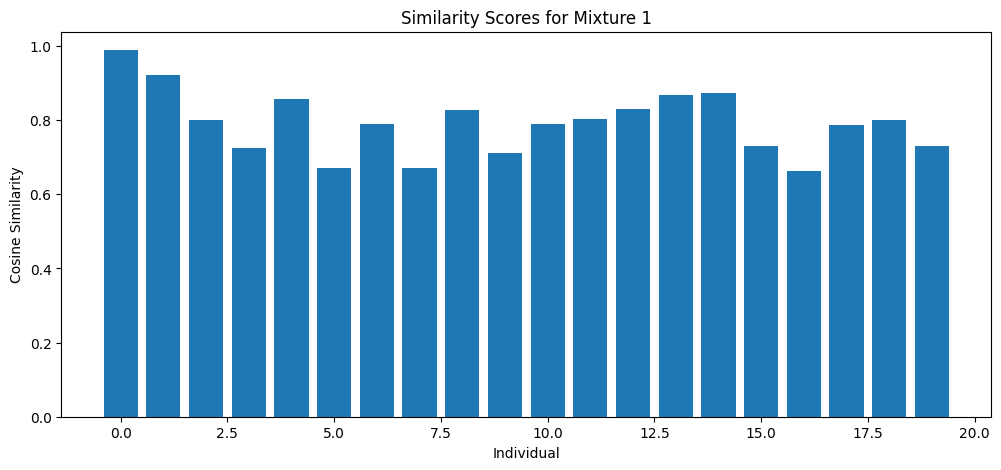

In [25]:
plt.figure(figsize=(12,5))

plt.bar(range(20), mix_similarity[0][:20])

plt.title("Similarity Scores for Mixture 1")
plt.xlabel("Individual")
plt.ylabel("Cosine Similarity")

plt.show()

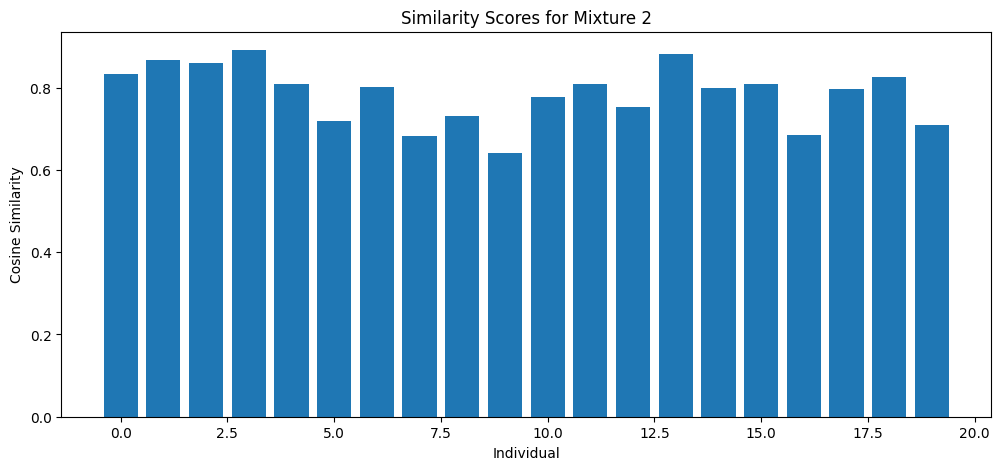

In [26]:
plt.figure(figsize=(12,5))

plt.bar(range(20), mix_similarity[1][:20])

plt.title("Similarity Scores for Mixture 2")
plt.xlabel("Individual")
plt.ylabel("Cosine Similarity")

plt.show()

In [27]:
from sklearn.decomposition import PCA

In [28]:
combined = np.vstack([reference, mixed_samples])

pca = PCA(n_components=2)

pca_result = pca.fit_transform(combined)

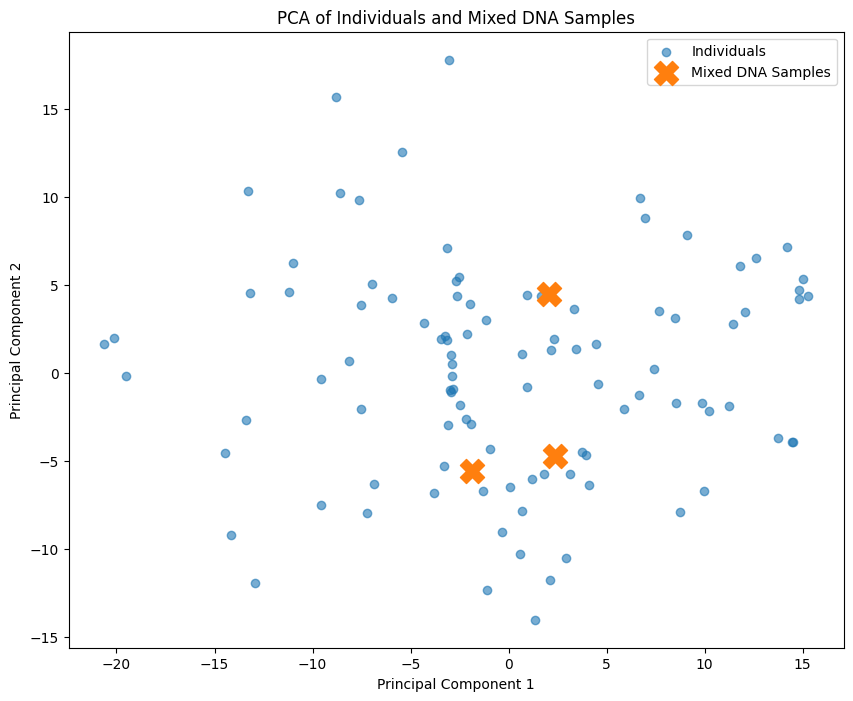

In [29]:
plt.figure(figsize=(10,8))

plt.scatter(
    pca_result[:100, 0],
    pca_result[:100, 1],
    alpha=0.6,
    label="Individuals"
)

plt.scatter(
    pca_result[100:, 0],
    pca_result[100:, 1],
    s=300,
    marker='X',
    label="Mixed DNA Samples"
)

plt.title("PCA of Individuals and Mixed DNA Samples")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend()

plt.show()

In [30]:
top_scores = np.sort(mix_similarity, axis=1)[:, -2:]

confidence = top_scores[:, 1] - top_scores[:, 0]

print(confidence)

[0.06726477 0.00882973 0.10089189]


In [31]:
for i, c in enumerate(confidence):
    print(f"Mixture {i+1} confidence: {abs(c):.4f}")

Mixture 1 confidence: 0.0673
Mixture 2 confidence: 0.0088
Mixture 3 confidence: 0.1009


In [32]:
from scipy.stats import entropy

In [33]:
probabilities = mix_similarity / mix_similarity.sum(axis=1, keepdims=True)

entropies = entropy(probabilities, axis=1)

print(entropies)

[4.60085189 4.60172211 4.59995946]


In [34]:
temperature = 0.05

scaled = np.exp(mix_similarity / temperature)

probabilities_sharp = scaled / scaled.sum(axis=1, keepdims=True)

sharp_entropy = entropy(probabilities_sharp, axis=1)

print(sharp_entropy)

[3.35644884 4.09525265 3.03051138]


In [35]:
for i, e in enumerate(sharp_entropy):
    print(f"Mixture {i+1} sharp entropy: {e:.4f}")

Mixture 1 sharp entropy: 3.3564
Mixture 2 sharp entropy: 4.0953
Mixture 3 sharp entropy: 3.0305


In [36]:
ratios = [0.5, 0.6, 0.7, 0.8, 0.9]

entropies = []
confidences = []

for r in ratios:

    mix = r * gn[:, 0] + (1-r) * gn[:, 1]

    mix = mix.reshape(1, -1)

    similarity = cosine_similarity(mix, reference)

    top_scores = np.sort(similarity, axis=1)[:, -2:]

    confidence = top_scores[:, 1] - top_scores[:, 0]

    scaled = np.exp(similarity / 0.05)

    probs = scaled / scaled.sum(axis=1, keepdims=True)

    e = entropy(probs, axis=1)

    confidences.append(abs(confidence[0]))
    entropies.append(e[0])

    print(f"Ratio {r:.1f}/{1-r:.1f} -> Confidence {confidence[0]:.4f}, Entropy {e[0]:.4f}")

Ratio 0.5/0.5 -> Confidence 0.0095, Entropy 3.5204
Ratio 0.6/0.4 -> Confidence 0.0389, Entropy 3.4684
Ratio 0.7/0.3 -> Confidence 0.0673, Entropy 3.3564
Ratio 0.8/0.2 -> Confidence 0.0944, Entropy 3.2035
Ratio 0.9/0.1 -> Confidence 0.1164, Entropy 3.0286


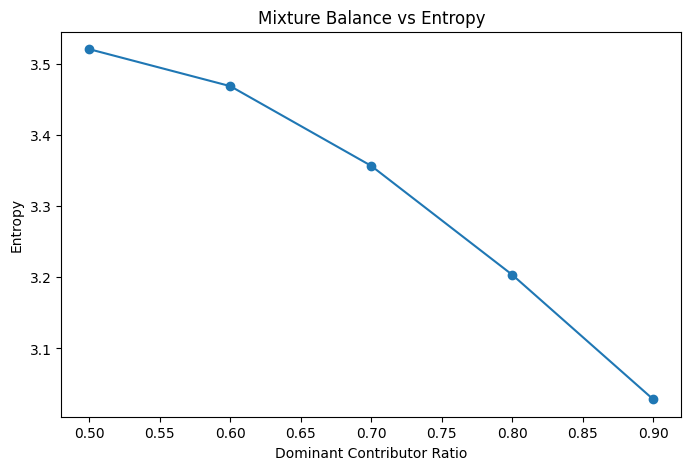

In [37]:
plt.figure(figsize=(8,5))

plt.plot(ratios, entropies, marker='o')

plt.title("Mixture Balance vs Entropy")
plt.xlabel("Dominant Contributor Ratio")
plt.ylabel("Entropy")

plt.show()

In [38]:
X = gn.T
y = np.arange(X.shape[0])

print(X.shape)
print(y.shape)

(100, 10000)
(100,)


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim

In [41]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [42]:
class GenomicClassifier(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(10000, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 100)
        )

    def forward(self, x):
        return self.network(x)

In [43]:
model = GenomicClassifier()

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [44]:
epochs = 50

losses = []

for epoch in range(epochs):
    model.train()

    optimizer.zero_grad()

    outputs = model(X_train_tensor)

    loss = criterion(outputs, y_train_tensor)

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 10/50, Loss: 3.1836
Epoch 20/50, Loss: 0.8927
Epoch 30/50, Loss: 0.0745
Epoch 40/50, Loss: 0.0099
Epoch 50/50, Loss: 0.0033


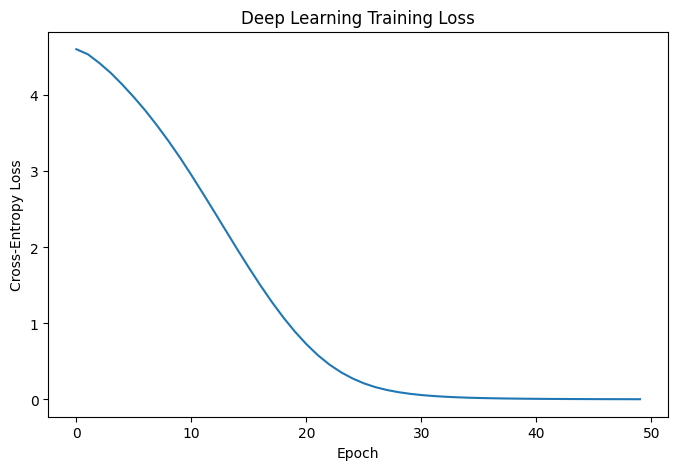

In [45]:
plt.figure(figsize=(8,5))
plt.plot(losses)
plt.title("Deep Learning Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.show()

In [46]:
model.eval()

with torch.no_grad():
    test_outputs = model(X_test_tensor)
    predictions = torch.argmax(test_outputs, dim=1)

accuracy = (predictions == y_test_tensor).float().mean().item()

print("Deep learning test accuracy:", accuracy)

Deep learning test accuracy: 0.0


In [47]:
embeddings = model.network[:-1](X_train_tensor).detach().numpy()

print(embeddings.shape)

(80, 128)


In [48]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

embedding_pca = pca.fit_transform(embeddings)

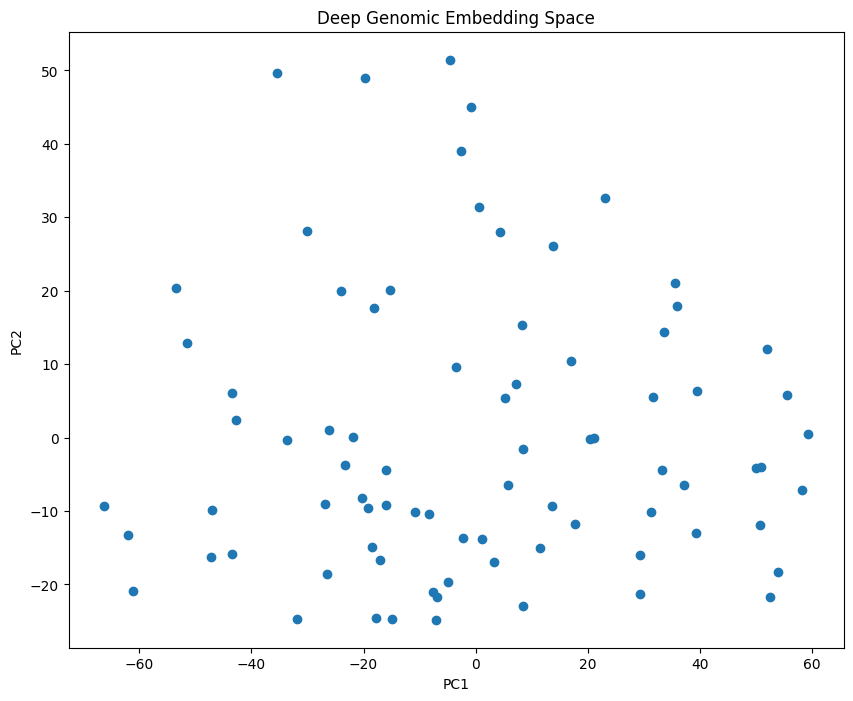

In [49]:
plt.figure(figsize=(10,8))

plt.scatter(
    embedding_pca[:,0],
    embedding_pca[:,1]
)

plt.title("Deep Genomic Embedding Space")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

In [50]:
import os

os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

In [51]:
plt.savefig("figures/nazwa_wykresu.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [52]:
import pandas as pd

degradation_results = pd.DataFrame({
    "degradation_level": degradation_levels,
    "identification_accuracy": accuracies
})

degradation_results.to_csv("results/degradation_results.csv", index=False)

mixture_results = pd.DataFrame({
    "dominant_contributor_ratio": ratios,
    "confidence": confidences,
    "entropy": entropies
})

mixture_results.to_csv("results/mixture_uncertainty_results.csv", index=False)